<a href="https://colab.research.google.com/github/vestrada-data/data-analytics/blob/main/mobility_economy_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Proyecto de Análisis de Movilidad y Productividad Urbana | Latin American Development Bank (simulado)

Evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar
Validar que los archivos se carguen correctamente, conocer las columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/data/tomtom_traffic.csv'`
  - `/data/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# cargar archivos
traffic = pd.read_csv('/content/tomtom_traffic.csv')
eco = pd.read_csv('/content/oecd_city_economy.csv')

In [3]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Inspecciona estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

In [5]:
# Examinar la estructura de traffic
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas 'UpdateTimeUTC','Country' y 'City' es información de interes
- Sera necesario cambiar 'UpdateTimeUTC' y UpdateTimeUtcWeekAgo' a formato datetime
- No hay valores asusentes en ninguna columna

In [6]:
# Examinar la estructura de eco
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas 'City GDP/capita', 'Unemployment %', PM2.5 (μg/m³),Population (M) : son de tipo objeto,
  sera necesario cambiar su formato para usarlas en datos estadísticos
- Year ya tiene formato de entero y Country formato de texto
- No hay columnas con valores ausentes

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

- Cambio los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`


In [7]:
# Estandarizar los nombres de las columnas de traffic con formato snake_case
new_columns = {'Country' : 'country',
 'UpdateTimeUTC': 'update_time_utc',
  'City': 'city', 'JamsDelay':'jams_delay',
  'TrafficIndexLive':'traffic_index_live',
  'JamsLengthInKms': 'jams_length_kms',
  'JamsCount':'jams_count',
  'TrafficIndexWeekAgo':'traffi_index_week_ago',
  'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago',
  'TravelTimeLivePer10KmsMins':'travel_time_live_per_10kms_mins',
  'TravelTimeHistoricPer10KmsMins':'travel_time_hist_per_10kms_mins',
'MinsDelay':'mins_delay'  }
traffic =traffic.rename(columns=new_columns)


# verificar cambios
traffic.columns


Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffi_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [8]:
# Estandarizar los nombres de las columnas de eco
new_columns_eco = {
        'Country' : 'country', 'Year':'year',
        'City': 'city',
        'UpdateTimeUTC': 'update_time_utc',
        'City GDP/capita': 'city_gdp_capita',
        'Unemployment %':'unemployment_pct',
        'PM2.5 (μg/m³)':'pm25',
        'Population (M)': 'population_m' }
eco=eco.rename(columns= new_columns_eco )

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

- Columnas de fecha de `traffic` a formato `datetime`.
- En el dataset `eco`, limpio los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles  y reemplaza las comas por puntos  antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje  y reemplaza las comas  por puntos  antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas por puntos antes de convertir a tipo `float`.
- Se crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffi_index_week_ago            1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [10]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').astype(float)
eco['pm25']=eco['pm25'].astype(str).str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']* 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Este paso facilita el análisis temporal y permite realizar agregaciones o comparativas por año de manera eficiente.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

- Como el DataFrame `traffic` no tiene una columna de año,  crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffi_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [12]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffi_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.


- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio *solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, para mantener las columnas como variables (no índices).


In [13]:
# Calcular los  promedios de trafico por ciudad, país y año

traffic_city_year_2024 =  traffic_2024.groupby(['city','country','year'],dropna=False).agg({'jams_delay':'mean','traffic_index_live':'mean','jams_length_kms':'mean', 'jams_count':'mean', 'mins_delay':'mean','travel_time_live_per_10kms_mins':'mean','travel_time_hist_per_10kms_mins':'mean'}).reset_index()
# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


###  **Análisis**
Ordenamos los resultados y observamos


In [14]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


## 🧩Paso 5: Unir movilidad y economía

Combinamos los  datasets para analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

- Crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como *claves de unión** a `city` y `year`.
- Mantenemos solo las ciudades y años presentes en ambos datasets.
- Guardamos el resultado en una nueva variable llamada `merged`


In [15]:
# Seleccionar columnas clave de tráfico y economía

left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','country','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged =pd.merge(traffic_2024_small,eco_2024_small, on=['city','year'], how='inner')

# Mostrar las primeras 5 filas
merged.columns
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   city                             15 non-null     object 
 1   country_x                        15 non-null     object 
 2   year                             15 non-null     int32  
 3   jams_delay                       15 non-null     float64
 4   traffic_index_live               15 non-null     float64
 5   jams_length_kms                  15 non-null     float64
 6   jams_count                       15 non-null     float64
 7   mins_delay                       15 non-null     float64
 8   travel_time_live_per_10kms_mins  15 non-null     float64
 9   travel_time_hist_per_10kms_mins  15 non-null     float64
 10  country_y                        15 non-null     object 
 11  city_gdp_capita                  15 non-null     float64
 12  unemployment_pct        


---

## 🧩Paso 6: Visualización y análisis de relaciones

Utilizando el dataset limpio y unificado, *visualizamos patrones** para entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.


- Usar las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - Analisis exploratorio con **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- *Comparar ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.


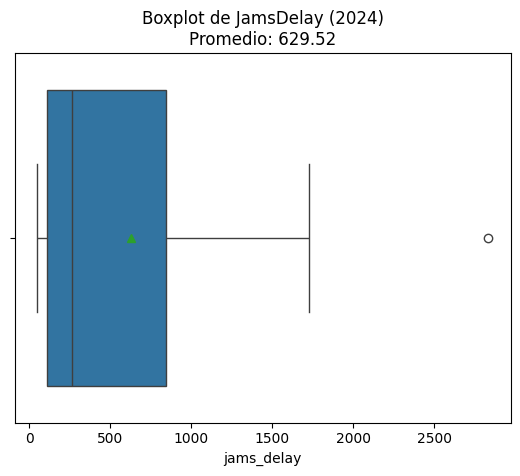

In [16]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
sns.boxplot(data=merged, x='jams_delay', showmeans=True)
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


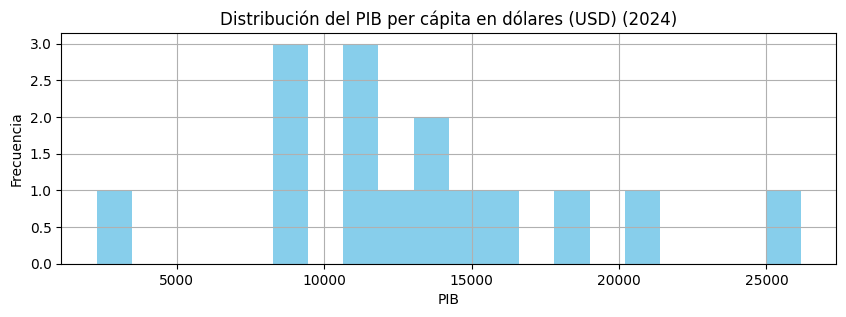

In [17]:
# Crear histogra# 2. Creamos el histograma usando el método de Pandas .hist()

merged['city_gdp_capita'].hist(bins=20, color='skyblue', figsize=(10, 3))
plt.title('Distribución del PIB per cápita en dólares (USD) (2024)')
plt.xlabel('PIB')
plt.ylabel('Frecuencia')
plt.show()



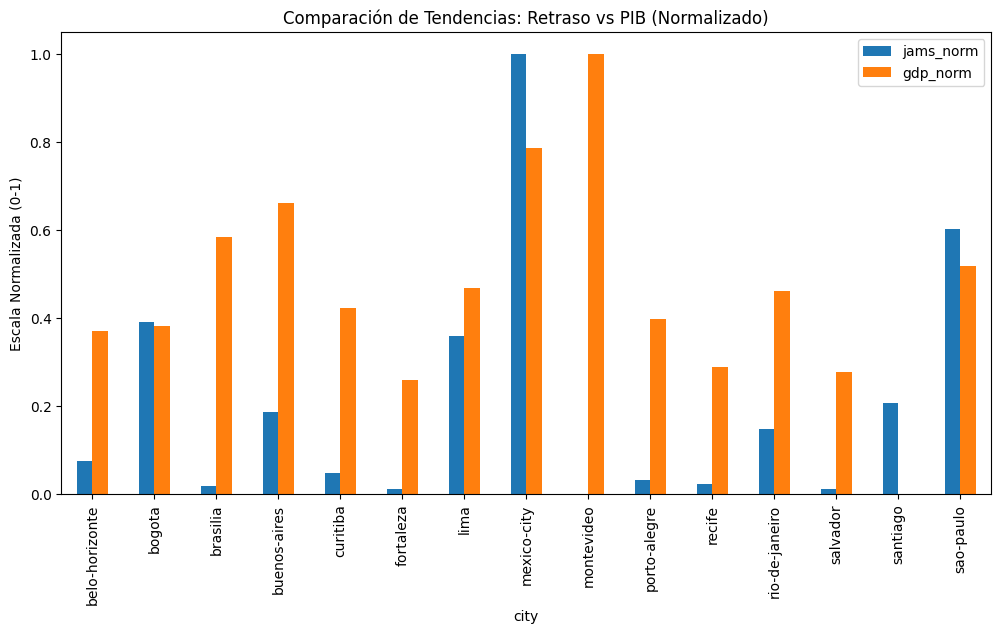

In [18]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad

# Crear columnas normalizadas
merged['jams_norm'] = (merged['jams_delay'] - merged['jams_delay'].min()) / (merged['jams_delay'].max() - merged['jams_delay'].min())
merged['gdp_norm'] = (merged['city_gdp_capita'] - merged['city_gdp_capita'].min()) / (merged['city_gdp_capita'].max() - merged['city_gdp_capita'].min())

# Graficar
merged.plot(kind='bar', x='city', y=['jams_norm', 'gdp_norm'], figsize=(12, 6))
plt.ylabel('Escala Normalizada (0-1)')
plt.title('Comparación de Tendencias: Retraso vs PIB (Normalizado)')
plt.xticks(rotation=90)
plt.show()



Escribe tus comentarios : No existe una relación clara ni consistente entre PIB per cápita y congestión, parece que hay otros factores que influyen.

In [20]:
# Exporta el dataset final como CSV
import os
# Path
path = "ladb_mobility_economy_2024_clean.csv"

#exportar archivo cvs
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

size = os.path.getsize(path)

print("Tamaño del archivo(en bytes) of '%s':" % path, size)

Tamaño del archivo(en bytes) of 'ladb_mobility_economy_2024_clean.csv': 3524


#  Resumen ejecutivo
**Contexto & objetivo:**

El objetivo del análisis fue evaluar la relación entre la movilidad urbana, medida a través de la congestión vehicular (minutos de retraso)  y la productividad económica, representada por el PIB per cápita. Estas variables son clave para la toma de decisiones, ya que permiten identificar si las limitaciones en infraestructura y transporte están afectando el desempeño económico de las ciudades.

**Cobertura de datos:**  
El análisis considera datos correspondientes a 2024, integrando información de 15 ciudadesde de América Latina en los siguientes países: Brasil, Colombia, Argentina, Perú, Mexico, Uruguay y Chile.

**Metodología (alto nivel):**  
Se realizó un proceso de limpieza y estandarización de datos, asegurando consistencia en formatos y nombres de variables. Posteriormente, se agregaron los datos a nivel ciudad-año y se integraron mediante una unión tipo INNER entre fuentes de movilidad y economía. Se emplearon visualizaciones: boxplot, histograma y comparaciones por ciudad para identificar distribuciones, posibles outliers y patrones generales.

**Hallazgos iniciales:**  
No se encontró una relación directa entre el PIB per cápita y la congestión vehicular. Existen ciudades con alto PIB y alta congestión vehicular, así como ciudades con menor PIB pero distintos niveles de tráfico.
Destacan ciudades como Lima y Ciudad de México, donde hay altos niveles de congestión vehicular pero un PIB per cápita que no es de los más altos, lo que sugiere que la congestión no depende únicamente del nivel económico, sino de factores como infraestructura, planeación urbana y transporte público.
Por otro lado, ciudades como Santiago muestran baja congestión vehicular y alto PIB, funcionando como un caso más eficiente.

**Recomendaciones**  
Se recomienda priorizar el análisis e inversión en ciudades como Lima y Ciudad de México, donde la congestión vehicular sugiere un mayor impacto negativo en la productividad. También se sugiere profundizar el análisis incorporando otras variables como uso de vehículo o transporte público, densidad poblacional y planeación urbana, así como validar datos y ampliar el análisis a más años para confirmar tendencias.


